### STA/LTA + AIC refine P-wave arrival time

In [1]:
%matplotlib widget
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tpc5
from scipy.signal import butter, filtfilt,hilbert

In [2]:
# ================== STA/LTA==================
BP_LO_HZ   = 1e3
BP_HI_HZ   = 8e5
BP_ORDER   = 4
STA_US     = 15.0       # STA 視窗長度（微秒）
LTA_US     = 100.0      # LTA 視窗長度（微秒）
TH_ON      = 3.0        # 觸發門檻
EPS        = 1e-12
# Young's modulus 參數
NU  = 0.35
RHO = 1148.0  # kg/m^3
sensor_positions = {1: 0.1, 2: 0.1281, 3: 0.1886}
channel_colors    = {1: 'C0', 2: 'C1', 3: 'C2'}

AIC_WINDOW_MS = 0.0015  # ms
USE_CHANNELS = {1: True, 2: True, 3:True}   # 例如：{1: False, 2:True, 3: True}

file_path = "../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_9.tpc5"

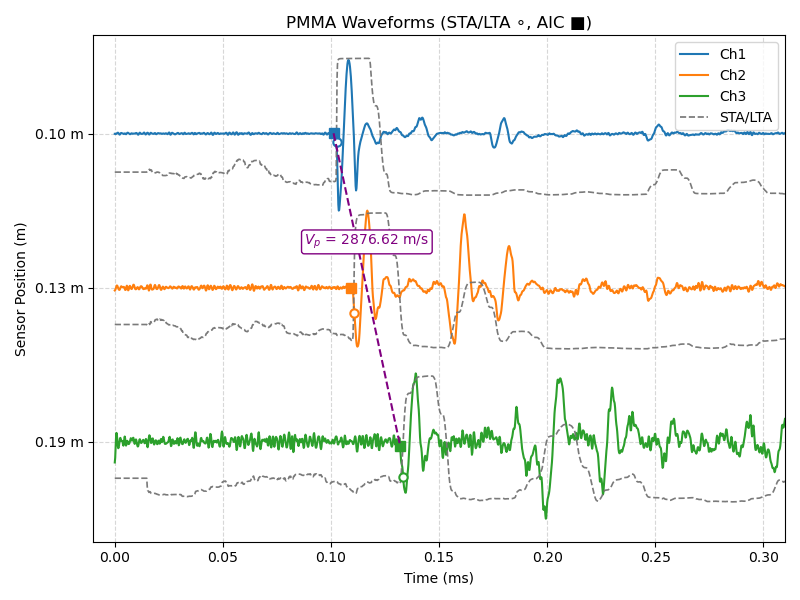


=== 每個 Channel 的到時（STA/LTA、AIC、採用值）===
Ch   y[m]      t_STA[s]       t_AIC[s]       t_used[s]    t_STA[ms]   t_AIC[ms]   t_used[ms]   t_STA[µs]   t_AIC[µs]   t_used[µs]
1    0.100    0.000102600    0.000101200    0.000101200   0.102600000   0.101200000   0.101200000   102.600000000   101.200000000   101.200000000
2    0.128    0.000110800    0.000109400    0.000109400   0.110800000   0.109400000   0.109400000   110.800000000   109.400000000   109.400000000
3    0.189    0.000133400    0.000132000    0.000132000   0.133400000   0.132000000   0.132000000   133.400000000   132.000000000   132.000000000

=== 通道配對的距離差 Δx、到時差 Δt、表觀波速 V 與 E ===
Pair   x1[m]   x2[m]   Δx[m]      t1[s]         t2[s]         Δt[s]        Δt[µs]     V[m/s]     E[GPa]
1- 2   0.100   0.128   +0.0281   0.000101200   0.000109400   0.000008200      8.200    3426.829      8.400
1- 3   0.100   0.189   +0.0886   0.000101200   0.000132000   0.000030800     30.800    2876.623      5.919
2- 3   0.128   0.189   +0.0605   0.

In [3]:
# ================== 工具函式 ==================# ================== 工具函式 ==================
def running_mean_causal(x, n):
    n = int(max(1, min(n, len(x))))
    c = np.cumsum(np.insert(x, 0, 0.0))
    valid = (c[n:] - c[:-n]) / n
    out = np.empty_like(x, dtype=float)
    out[:n-1] = valid[0]
    out[n-1:] = valid
    return out

def classic_sta_lta_causal(x, nsta, nlta):
    nsta = int(max(1, min(nsta, len(x))))
    nlta = int(max(nsta+1, min(nlta, len(x))))
    e = x * x
    sta = running_mean_causal(e, nsta)
    lta = running_mean_causal(e, nlta) + EPS
    return sta / lta

def trigger_onset_first_over(ratio, th_on):
    idx = np.where(ratio >= th_on)[0]
    return int(idx[0]) if idx.size else None

def aic_pick(env):
    """AIC 變點（在包絡上）：argmin[ k ln var(e[:k]) + (N-k-1) ln var(e[k:]) ]"""
    N = len(env)
    if N < 5:
        return None
    aic = np.full(N, np.inf, dtype=float)
    for k in range(1, N-1):
        v1 = np.var(env[:k]) + EPS
        v2 = np.var(env[k:]) + EPS
        aic[k] = k*np.log(v1) + (N-k-1)*np.log(v2)
    return int(np.argmin(aic))

def young_from_vp(vp, rho=RHO, nu=NU):
    """E = Vp^2 * rho * (1+nu) * (1-2nu) / (1-nu)"""
    return (vp**2) * rho * (1.0 + nu) * (1.0 - 2.0*nu) / (1.0 - nu)

# ================== 主流程（讀檔、挑到時） ==================
with h5py.File(file_path, 'r') as f:
    ch_group  = f['/measurements/00000001/channels']
    available = sorted(int(ch) for ch in ch_group.keys())
    ch_list   = [ch for ch in available if (ch in sensor_positions and USE_CHANNELS.get(ch, False))]

    if not ch_list:
        raise RuntimeError("沒有啟用的通道（請調整 USE_CHANNELS）。")

    all_times, all_wave_norm, all_stalta_plot = [], [], []
    arrival_times_sta, arrival_times_aic, plotted_channels = [], [], []

    for ch in ch_list:
        v  = tpc5.getVoltageData(f, ch)
        fs = tpc5.getSampleRate(f, ch)
        dt = 1.0 / fs
        t  = np.linspace(0, dt*(len(v)-1), len(v))
        t -= 0.12572

        # 只看 0 ~ 0.5 ms
        m = (t >= 0) & (t <= 0.0005)
        if not np.any(m):
            continue
        t = t[m]; v = v[m]

        # Band-pass（先濾）
        nyq = 0.5 * fs
        lo = max(BP_LO_HZ / nyq, 1e-6)
        hi = min(BP_HI_HZ, 0.45 * fs) / nyq
        if hi <= lo * 1.05:
            hi = min(0.49, lo * 1.5)
        b, a = butter(BP_ORDER, [lo, hi], btype='band')
        v_bp = filtfilt(b, a, v)

        # dv/dt 與 STA/LTA
        dvdt = np.gradient(v_bp, dt)
        nsta = max(1, int(round(STA_US * 1e-6 * fs)))
        nlta = max(nsta + 1, int(round(LTA_US * 1e-6 * fs)))
        ratio = classic_sta_lta_causal(dvdt, nsta, nlta)

        # STA/LTA 粗到時
        idx_on = trigger_onset_first_over(ratio, TH_ON)
        t_pick_sta = t[idx_on] if idx_on is not None else None
        arrival_times_sta.append((t_pick_sta, sensor_positions[ch]))

        # AIC 精修（±0.002 ms）
        t_pick_aic = None
        if idx_on is not None:
            half = max(3, int(round((AIC_WINDOW_MS * 1e-3) * fs)))
            s = max(0, idx_on - half)
            e = min(len(dvdt), idx_on + half + 1)
            if e - s >= 5:
                env = np.abs(hilbert(dvdt[s:e]))
                kmin = aic_pick(env)
                if kmin is not None:
                    idx_aic = s + kmin
                    t_pick_aic = t[idx_aic]
        arrival_times_aic.append((t_pick_aic, sensor_positions[ch]))

        # 繪圖用資料
        amp  = np.max(np.abs(dvdt)) or 1.0
        wnorm = dvdt / amp
        st_overlay = (ratio / TH_ON - 1.0) * 0.8  # 灰線（=0 代表達門檻）

        all_times.append(t)
        all_wave_norm.append(wnorm)
        all_stalta_plot.append(st_overlay)
        plotted_channels.append(ch)

# ================== 繪圖（Ch1 置頂） ==================
fig, ax = plt.subplots(figsize=(8, 6))
y_spacing = 2.0
n = len(all_times)
y_offsets = [(n-1 - i) * y_spacing for i in range(n)]  # 由上到下

y_ticks, y_labels = [], []
for i, (t, w, st) in enumerate(zip(all_times, all_wave_norm, all_stalta_plot)):
    yoff = y_offsets[i]
    ch   = plotted_channels[i]
    col  = channel_colors.get(ch, 'k')

    ax.plot(t*1e3, w + yoff, color=col, label=f"Ch{ch}")                     # 波形
    ax.plot(t*1e3, st + yoff, '--', lw=1.2, color='0.45', alpha=0.95)        # STA/LTA 灰線

    # STA/LTA 到時（圓點）
    t_sta, _ = arrival_times_sta[i]
    if t_sta is not None:
        j = np.argmin(np.abs(t - t_sta))
        ax.plot(t_sta*1e3, w[j] + yoff, marker='o', ms=6,
                mfc='white', mec=col, mew=1.5, linestyle='None')

    # AIC 精修到時（方塊）
    t_aic, _ = arrival_times_aic[i]
    if t_aic is not None:
        j2 = np.argmin(np.abs(t - t_aic))
        ax.plot(t_aic*1e3, w[j2] + yoff, marker='s', ms=7,
                mfc=col, mec=col, mew=1.0, linestyle='None')

    y_ticks.append(yoff)
    y_labels.append(f"{sensor_positions[ch]:.2f} m")

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Sensor Position (m)")
ax.set_title("PMMA Waveforms (STA/LTA ∘, AIC ■)")
ax.set_xlim(-0.01, 0.31)
ax.grid(True, linestyle='--', alpha=0.5)

# ================== 以偏好到時(優先 AIC)估算 Vp（紫線） ==================
def prefer_aic(arr_aic, arr_sta):
    out = []
    for (taic, y), (tsta, _) in zip(arr_aic, arr_sta):
        out.append((taic if taic is not None else tsta, y))
    return out

pref_times = prefer_aic(arrival_times_aic, arrival_times_sta)
valid_idx = [i for i,(tp,_) in enumerate(pref_times) if tp is not None]

Vp = None  # 先佔位
if len(valid_idx) >= 2:
    top_i, bot_i = valid_idx[0], valid_idx[-1]
    t_top, y1 = pref_times[top_i]
    t_bot, y2 = pref_times[bot_i]

    k_top = np.argmin(np.abs(all_times[top_i] - t_top))
    k_bot = np.argmin(np.abs(all_times[bot_i] - t_bot))
    y_top = y_offsets[top_i] + all_wave_norm[top_i][k_top]
    y_bot = y_offsets[bot_i] + all_wave_norm[bot_i][k_bot]

    ax.plot([t_top*1e3, t_bot*1e3], [y_top, y_bot], '--', color='purple', lw=1.5)
    Vp = (y2 - y1) / (t_bot - t_top)

    ax.text(((t_top+t_bot)/2)*1e3, (y_top+y_bot)/2 + 0.5, f"$V_p$ = {Vp:.2f} m/s",
            color='purple', fontsize=10, ha='center', va='bottom',
            bbox=dict(facecolor='white', edgecolor='purple', boxstyle='round,pad=0.2'))

# 圖例（把 STA/LTA 灰線放最後）
st_handle = ax.plot([], [], '--', lw=1.2, color='0.45', label='STA/LTA')[0]
handles, labels = ax.get_legend_handles_labels()
if st_handle not in handles:
    handles.append(st_handle); labels.append('STA/LTA')
ax.legend(handles, labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ================== 列印到時與配對差值 + Young's modulus ==================
# 每通道到時（STA、AIC、採用值）
records = []
for i, ch in enumerate(plotted_channels):
    y      = sensor_positions[ch]
    t_sta  = arrival_times_sta[i][0]
    t_aic  = arrival_times_aic[i][0]
    t_used = pref_times[i][0]
    records.append({"ch": ch, "y": y, "t_sta": t_sta, "t_aic": t_aic, "t_used": t_used})

records_sorted = sorted(records, key=lambda r: r["ch"])

print("\n=== 每個 Channel 的到時（STA/LTA、AIC、採用值）===")
print("Ch   y[m]      t_STA[s]       t_AIC[s]       t_used[s]    "
      "t_STA[ms]   t_AIC[ms]   t_used[ms]   t_STA[µs]   t_AIC[µs]   t_used[µs]")
def ffmt(x, scale=1.0):
    return f"{x*scale: .9f}" if x is not None else "     None   "
for r in records_sorted:
    print(f"{r['ch']:<3d} {r['y']:>6.3f}  {ffmt(r['t_sta']):>13}  {ffmt(r['t_aic']):>13}  {ffmt(r['t_used']):>13}  "
          f"{ffmt(r['t_sta'],1e3):>10}  {ffmt(r['t_aic'],1e3):>10}  {ffmt(r['t_used'],1e3):>10}  "
          f"{ffmt(r['t_sta'],1e6):>10}  {ffmt(r['t_aic'],1e6):>10}  {ffmt(r['t_used'],1e6):>10}")

# 通道配對 Δx、Δt、V 與 E
print("\n=== 通道配對的距離差 Δx、到時差 Δt、表觀波速 V 與 E ===")
print("Pair   x1[m]   x2[m]   Δx[m]      t1[s]         t2[s]         Δt[s]        Δt[µs]     V[m/s]     E[GPa]")
for i in range(len(records_sorted)):
    for j in range(i+1, len(records_sorted)):
        r1, r2 = records_sorted[i], records_sorted[j]
        t1, t2 = r1["t_used"], r2["t_used"]
        if (t1 is None) or (t2 is None):
            continue
        x1, x2 = r1["y"], r2["y"]
        dx = x2 - x1
        dt = t2 - t1
        V  = dx / dt if dt != 0 else float("inf")
        E_pair = young_from_vp(abs(V))  # E ∝ V^2，取絕對值即可
        print(f"{r1['ch']}-{r2['ch']:>2}  {x1:>6.3f}  {x2:>6.3f}  {dx:>+8.4f}  "
              f"{t1: .9f}  {t2: .9f}  {dt: .9f}  {dt*1e6:>9.3f}   {V:>9.3f}   {E_pair/1e9:>8.3f}")

# 以紫線 Vp 計算全域 E
if Vp is not None and np.isfinite(Vp):
    E_global = young_from_vp(abs(Vp))
    print("\n=== Young's modulus from global Vp (top–bottom) ===")
    print("公式: E = Vp^2 * ρ * (1+ν) * (1-2ν) / (1-ν)")
    print(f"ν = {NU:.2f}, ρ = {RHO:.1f} kg/m^3,  Vp = {Vp:.3f} m/s")
    print(f"→ E = {E_global:.3e} Pa  = {E_global/1e9:.3f} GPa")
else:
    print("\n[警告] 無法由兩端通道得到有效 Vp（到時不足或 Δt≈0），全域 E 未計算。")


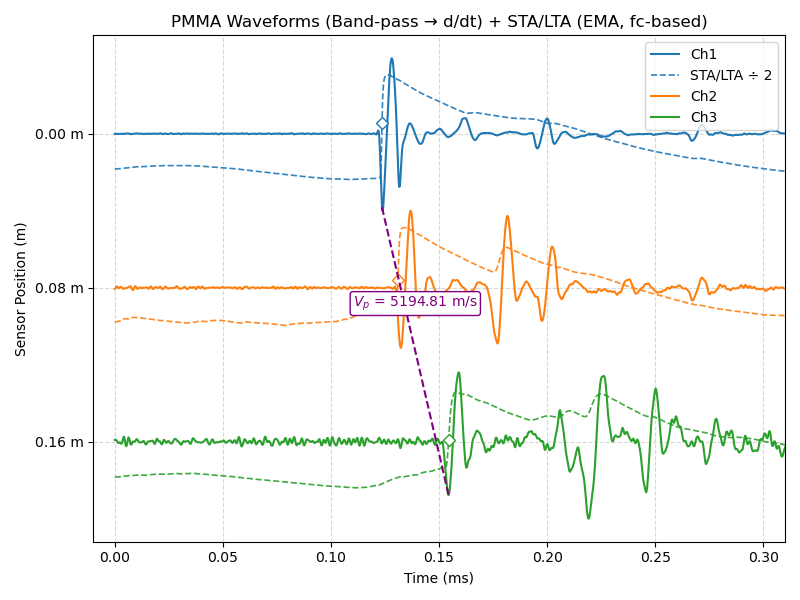

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tpc5
from scipy.signal import butter, filtfilt

# ===== 濾波與 STA/LTA 參數 =====
BP_LO_HZ        = 1e3
BP_HI_HZ        = 5e5
BP_ORDER        = 4
THRESH_STALTA   = 2.0        # 觸發門檻（比值）
STA_CYCLES      = 10         # 依 fc 決定窗長：STA = 10 週期
LTA_CYCLES      = 100        # LTA = 100 週期
EPS             = 1e-12

# 感測器位置與顏色
sensor_positions = {1: 0.0, 2: 0.08, 3: 0.16}
channel_colors    = {1: 'C0', 2: 'C1', 3: 'C2'}

file_path = "C:/Users/asd10/Desktop/PZT/Wavespeed/data/t0076_1mm_60cm_9.tpc5"
file_path = "../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_9.tpc5"

# -------- 單邊遞迴平均（EMA） ----------
def ema_running(x, N, init=None):
    """
    單邊（因果）指數移動平均：只依賴過去樣本。
    N ~ 等效窗長（樣本數）。alpha=1/N。
    """
    N = max(int(N), 1)
    alpha = 1.0 / N
    out = np.empty_like(x, dtype=float)
    out[0] = (np.mean(x[:min(len(x), N)]) if init is None else float(init))
    for i in range(1, len(x)):
        out[i] = (1.0 - alpha) * out[i-1] + alpha * x[i]
    return out

with h5py.File(file_path, 'r') as f:
    ch_group  = f['/measurements/00000001/channels']
    available = sorted(int(ch) for ch in ch_group.keys())
    ch_list   = [ch for ch in available if ch in sensor_positions]

    all_times, all_wave_norm, all_stalta_plot = [], [], []
    arrival_times_sta, plotted_channels = [], []

    for ch in ch_list:
        v  = tpc5.getVoltageData(f, ch)
        fs = tpc5.getSampleRate(f, ch)
        dt = 1.0 / fs
        t  = np.linspace(0, dt*(len(v)-1), len(v))
        t -= 0.1257

        # 只看 0 ~ 0.5 ms
        m = (t >= 0) & (t <= 0.0005)
        if not np.any(m):
            continue
        t = t[m]; v = v[m]; n = len(v)

        # ----- band-pass（微分前） -----
        nyq = 0.5 * fs
        lo = max(BP_LO_HZ / nyq, 1e-6)
        hi = min(BP_HI_HZ, 0.45 * fs) / nyq
        if hi <= lo * 1.05:
            hi = min(0.49, lo * 1.5)
        b, a = butter(BP_ORDER, [lo, hi], btype='band')
        v_bp = filtfilt(b, a, v)

        # ----- 以 fc 決定 STA/LTA 樣本數（同你提供的邏輯）-----
        Y = np.fft.rfft(v_bp)
        F = np.fft.rfftfreq(n, d=1/fs)
        if len(F) > 1:
            peak_idx = np.argmax(np.abs(Y[1:])) + 1  # 避開 DC
            fc = float(F[peak_idx])
        else:
            fc = 0.0

        if fc <= 0:
            sta_n, lta_n = 1, 2
        else:
            sta_n_raw = int(round(STA_CYCLES  * fs / fc))
            lta_n_raw = int(round(LTA_CYCLES * fs / fc))
            # 夾住避免過長；LTA 至少比 STA 長
            sta_n = max(1, min(sta_n_raw, max(4, n // 8)))
            lta_n = max(sta_n + 1, min(lta_n_raw, max(sta_n*3, n // 2)))

        # ----- 單邊 STA/LTA（只用過去資料）-----
        energy = v_bp**2
        # LTA 以最前面 10% 噪聲平均作為初值，避免一開始太小
        warm_len = max(1, int(0.1 * n))
        lta_init = np.mean(energy[:warm_len])
        sta = ema_running(energy, sta_n)
        lta = ema_running(energy, lta_n, init=lta_init) + EPS
        ratio = sta / lta

        # ----- 觸發：門檻=3 的首次超越；若沒有就取最大 ratio 作備援 -----
        idx_over = np.where(ratio >= THRESH_STALTA)[0]
        if idx_over.size:
            pick_idx = int(idx_over[0])
        else:
            pick_idx = int(np.argmax(ratio))  # 備援，不改門檻

        t_pick = t[pick_idx]
        arrival_times_sta.append((t_pick, sensor_positions[ch]))

        # ----- 微分後波形（畫圖）-----
        dvdt = np.gradient(v_bp, dt)
        amp  = np.max(np.abs(dvdt)) or 1.0
        wnorm = dvdt / amp

        # 疊在該通道上的 STA/LTA 曲線（縮放到 ~±0.8；0 表示剛好達門檻）
        st_overlay = (ratio / THRESH_STALTA - 1.0) * 0.8

        all_times.append(t)
        all_wave_norm.append(wnorm)
        all_stalta_plot.append(st_overlay)
        plotted_channels.append(ch)

# ====== 繪圖（Ch1 置頂）======
fig, ax = plt.subplots(figsize=(8, 6))
y_spacing = 2.0
n = len(all_times)
y_offsets = [(n-1 - i) * y_spacing for i in range(n)]

y_ticks, y_labels = [], []
legend_added = False

for i, (t, w, st) in enumerate(zip(all_times, all_wave_norm, all_stalta_plot)):
    yoff = y_offsets[i]
    ch   = plotted_channels[i]
    col  = channel_colors.get(ch, 'k')

    ax.plot(t*1e3, w + yoff, color=col, label=f"Ch{ch}")
    ax.plot(t*1e3, st + yoff, '--', lw=1.2, color=col,
            alpha=0.9, label=None if legend_added else f"STA/LTA ÷ {THRESH_STALTA:g}")
    legend_added = True

    # 門檻點（或備援點）標示在 STA/LTA 曲線上
    t_pick, _ = arrival_times_sta[i]
    j = np.argmin(np.abs(t - t_pick))
    ax.plot(t_pick*1e3, st[j] + yoff, marker='D', ms=6,
            mfc='white', mec=col, linestyle='None')

    y_ticks.append(yoff)
    y_labels.append(f"{sensor_positions[ch]:.2f} m")

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Sensor Position (m)")
ax.set_title("PMMA Waveforms (Band-pass → d/dt) + STA/LTA (EMA, fc-based)")
ax.set_xlim(-0.01, 0.31)
ax.grid(True, linestyle='--', alpha=0.5)

# 以 STA/LTA 到達時間計算 Vp（最上/最下）
if arrival_times_sta and arrival_times_sta[0][0] is not None and arrival_times_sta[-1][0] is not None:
    top_i, bot_i = 0, len(arrival_times_sta) - 1
    t_top, y1 = arrival_times_sta[top_i]
    t_bot, y2 = arrival_times_sta[bot_i]

    k_top = np.argmin(np.abs(all_times[top_i] - t_top))
    k_bot = np.argmin(np.abs(all_times[bot_i] - t_bot))
    y_top = y_offsets[top_i] + all_wave_norm[top_i][k_top]
    y_bot = y_offsets[bot_i] + all_wave_norm[bot_i][k_bot]

    ax.plot([t_top*1e3, t_bot*1e3], [y_top, y_bot], '--', color='purple', lw=1.5)
    Vp = (y2 - y1) / (t_bot - t_top)
    ax.text(((t_top+t_bot)/2)*1e3, (y_top+y_bot)/2 + 0.5, f"$V_p$ = {Vp:.2f} m/s",
            color='purple', fontsize=10, ha='center', va='bottom',
            bbox=dict(facecolor='white', edgecolor='purple', boxstyle='round,pad=0.2'))

ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

